In [4]:
import pandas as pd
import sqlite3 as sqlite
import matplotlib.pyplot as plt
conn = sqlite.connect('data/database.sqlite')

In [8]:
data = pd.read_sql("""select countryName , indicatorname , value , year from indicators
where countrycode = "EGY"
and indicatorname in ('GDP growth (annual %)' ) and year between 2000 and 2015
order by year desc """,conn)
data


,CountryName,IndicatorName,Value,Year
0,"Egypt, Arab Rep.",GDP growth (annual %),2.200000,2014
1,"Egypt, Arab Rep.",GDP growth (annual %),2.109136,2013
2,"Egypt, Arab Rep.",GDP growth (annual %),2.191847,2012
3,"Egypt, Arab Rep.",GDP growth (annual %),1.821844,2011
4,"Egypt, Arab Rep.",GDP growth (annual %),5.138986,2010
5,"Egypt, Arab Rep.",GDP growth (annual %),4.685041,2009
6,"Egypt, Arab Rep.",GDP growth (annual %),7.152203,2008
7,"Egypt, Arab Rep.",GDP growth (annual %),7.087827,2007
8,"Egypt, Arab Rep.",GDP growth (annual %),6.843838,2006
9,"Egypt, Arab Rep.",GDP growth (annual %),4.471744,2005


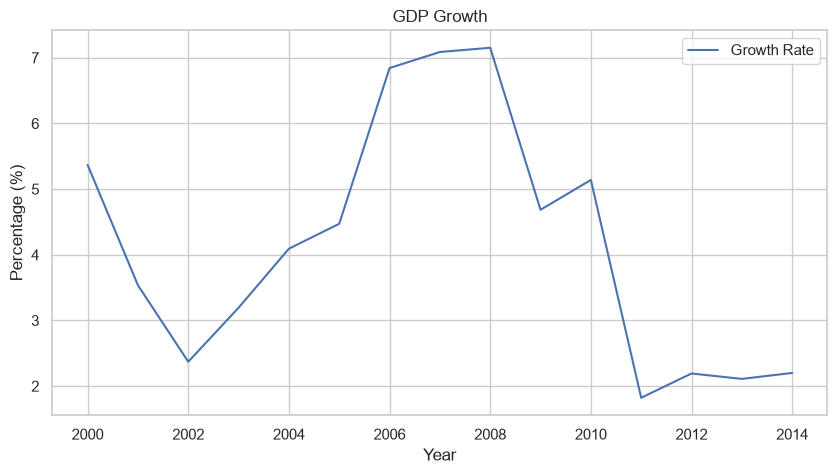

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(data["Year"], data["Value"], label="Growth Rate")
plt.title("GDP Growth")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
data = pd.read_sql("""select countryName , indicatorname , value , year from indicators
where countrycode = "EGY"
and indicatorname like "Unemployment, total (% of total labor force)" and year between 2000 and 2015
order by year desc """,conn)
data

,CountryName,IndicatorName,Value,Year
0,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",13.2,2014
1,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",13.2,2013
2,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",12.7,2012
3,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",12.0,2011
4,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",9.0,2010
5,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",9.4,2009
6,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",8.7,2008
7,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",8.9,2007
8,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",10.6,2006
9,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",11.2,2005


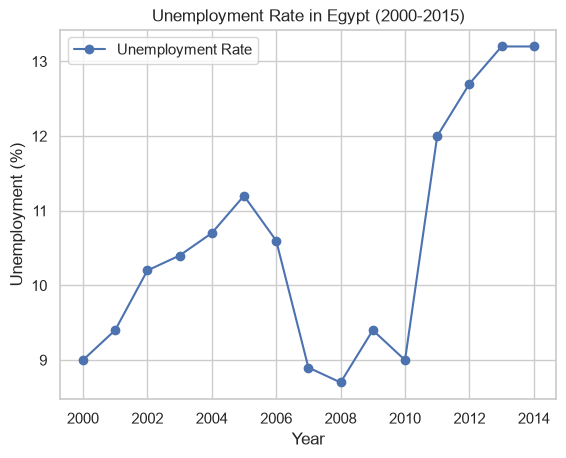

In [11]:
plt.plot(data['Year'], data['Value'], label='Unemployment Rate', marker='o')
plt.xlabel('Year')
plt.ylabel('Unemployment (%)')
plt.title('Unemployment Rate in Egypt (2000-2015)')
plt.grid(True)
plt.legend()
plt.show()

In [12]:
data = pd.read_sql("""
    select countryName, indicatorname, value, year from indicators
    where countrycode = 'EGY'
    and indicatorname in (
        'GDP growth (annual %)',
        'Unemployment, total (% of total labor force)'
    )
    and year between 2000 and 2015
    order by year desc
""", conn)

data

,CountryName,IndicatorName,Value,Year
0,"Egypt, Arab Rep.",GDP growth (annual %),2.200000,2014
1,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",13.200000,2014
2,"Egypt, Arab Rep.",GDP growth (annual %),2.109136,2013
3,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",13.200000,2013
4,"Egypt, Arab Rep.",GDP growth (annual %),2.191847,2012
5,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",12.700000,2012
6,"Egypt, Arab Rep.",GDP growth (annual %),1.821844,2011
7,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",12.000000,2011
8,"Egypt, Arab Rep.",GDP growth (annual %),5.138986,2010
9,"Egypt, Arab Rep.","Unemployment, total (% of total labor force)",9.000000,2010


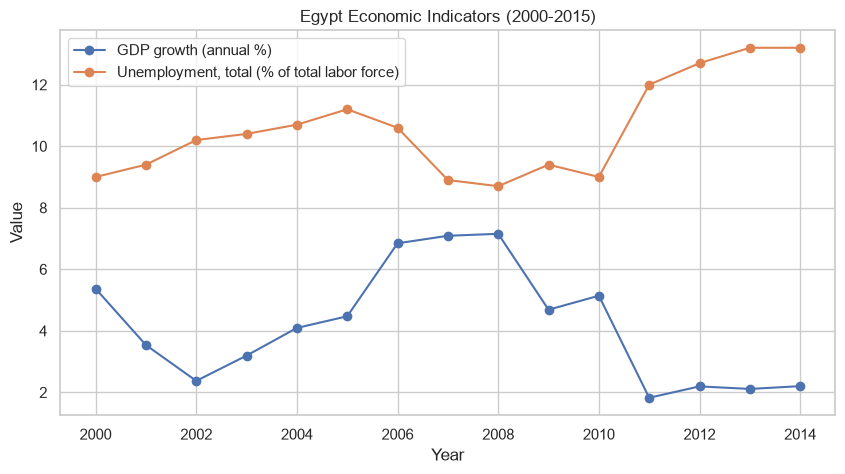

In [13]:
pivot_data = data.pivot(index='Year', columns='IndicatorName', values='Value')

plt.figure(figsize=(10, 5))
for column in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[column], marker='o', label=column)

plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Egypt Economic Indicators (2000-2015)')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
data = pd.read_sql("""
    select countryName, indicatorname, value, year from indicators
    where countrycode in ('EGY', 'NGA')
    and indicatorname = 'GDP growth (annual %)'
    and year between 2000 and 2015
    order by year asc;
""", conn)
data


,CountryName,IndicatorName,Value,Year
0,"Egypt, Arab Rep.",GDP growth (annual %),5.368006,2000
1,Nigeria,GDP growth (annual %),5.318093,2000
2,"Egypt, Arab Rep.",GDP growth (annual %),3.535226,2001
3,Nigeria,GDP growth (annual %),4.411065,2001
4,"Egypt, Arab Rep.",GDP growth (annual %),2.370489,2002
5,Nigeria,GDP growth (annual %),3.784648,2002
6,"Egypt, Arab Rep.",GDP growth (annual %),3.193455,2003
7,Nigeria,GDP growth (annual %),10.354185,2003
8,"Egypt, Arab Rep.",GDP growth (annual %),4.092072,2004
9,Nigeria,GDP growth (annual %),33.735775,2004


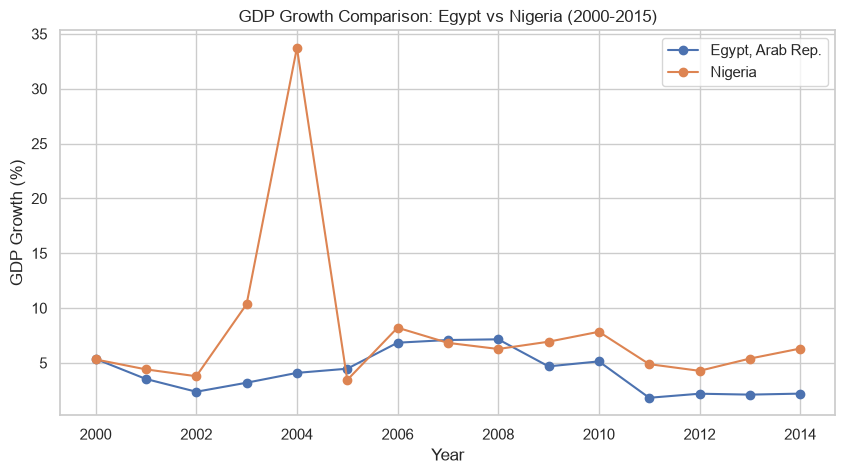

In [15]:
pivot_data = data.pivot(index='Year', columns='CountryName', values='Value')

plt.figure(figsize=(10, 5))
for column in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[column], marker='o', label=column)

plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.title('GDP Growth Comparison: Egypt vs Nigeria (2000-2015)')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
data = pd.read_sql("""select countryname, year , value , indicatorname from indicators
where countrycode in ('EGY','TUR')
and indicatorname = 'GDP growth (annual %)'
and year between 2000 and 2015
order by year desc;""",conn)
data

,CountryName,Year,Value,IndicatorName
0,"Egypt, Arab Rep.",2014,2.200000,GDP growth (annual %)
1,Turkey,2014,2.914143,GDP growth (annual %)
2,"Egypt, Arab Rep.",2013,2.109136,GDP growth (annual %)
3,Turkey,2013,4.192509,GDP growth (annual %)
4,"Egypt, Arab Rep.",2012,2.191847,GDP growth (annual %)
5,Turkey,2012,2.127461,GDP growth (annual %)
6,"Egypt, Arab Rep.",2011,1.821844,GDP growth (annual %)
7,Turkey,2011,8.772748,GDP growth (annual %)
8,"Egypt, Arab Rep.",2010,5.138986,GDP growth (annual %)
9,Turkey,2010,9.156953,GDP growth (annual %)


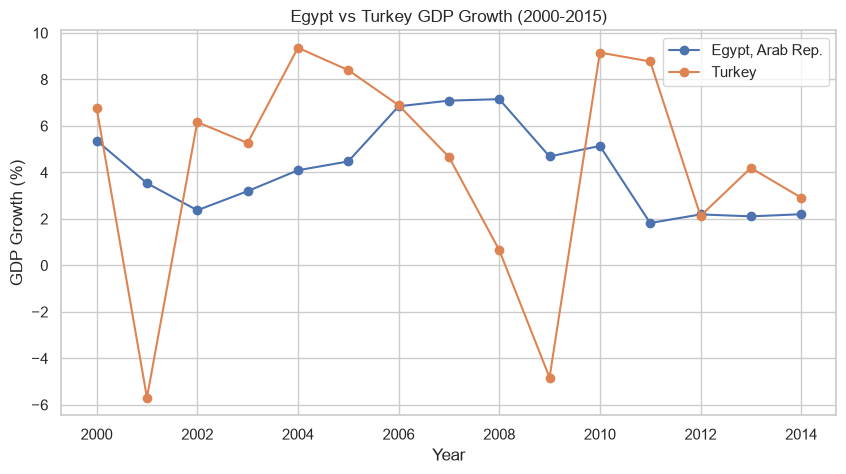

In [17]:
pivot_data = data.pivot(index='Year', columns='CountryName', values='Value')

plt.figure(figsize=(10, 5))
for column in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[column], marker='o', label=column)

plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.title('Egypt vs Turkey GDP Growth (2000-2015)')
plt.grid(True)
plt.legend()
plt.show()

In [18]:
data = pd.read_sql("""select countryname, year , value , indicatorname from indicators
where countrycode in ('EGY' , 'PAK')
and indicatorname = 'GDP growth (annual %)'
and year between 2000 and 2015
order by year desc;""",conn)
data

,CountryName,Year,Value,IndicatorName
0,"Egypt, Arab Rep.",2014,2.200000,GDP growth (annual %)
1,Pakistan,2014,4.738355,GDP growth (annual %)
2,"Egypt, Arab Rep.",2013,2.109136,GDP growth (annual %)
3,Pakistan,2013,4.367249,GDP growth (annual %)
4,"Egypt, Arab Rep.",2012,2.191847,GDP growth (annual %)
5,Pakistan,2012,3.507033,GDP growth (annual %)
6,"Egypt, Arab Rep.",2011,1.821844,GDP growth (annual %)
7,Pakistan,2011,2.748403,GDP growth (annual %)
8,"Egypt, Arab Rep.",2010,5.138986,GDP growth (annual %)
9,Pakistan,2010,1.606692,GDP growth (annual %)


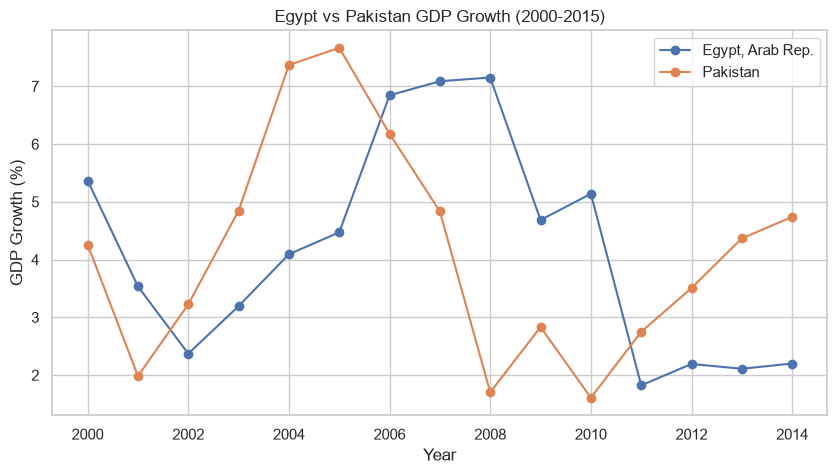

In [19]:
pivot_data = data.pivot(index='Year', columns='CountryName', values='Value')

plt.figure(figsize=(10, 5))
for column in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[column], marker='o', label=column)

plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.title('Egypt vs Pakistan GDP Growth (2000-2015)')
plt.grid(True)
plt.legend()
plt.show()

In [20]:
data = pd.read_sql("""select countryname , avg(value) as AVG_VALUE , indicatorname from indicators
where countrycode in ('EGY' , 'PAK' , 'TUR' , 'NGA')
and indicatorname = 'GDP growth (annual %)'
and year between 2000 and 2015
group by countrycode
order by year desc;""",conn)
data


,CountryName,AVG_VALUE,IndicatorName
0,Turkey,4.321957,GDP growth (annual %)
1,Pakistan,4.124024,GDP growth (annual %)
2,Nigeria,7.866868,GDP growth (annual %)
3,"Egypt, Arab Rep.",4.150781,GDP growth (annual %)


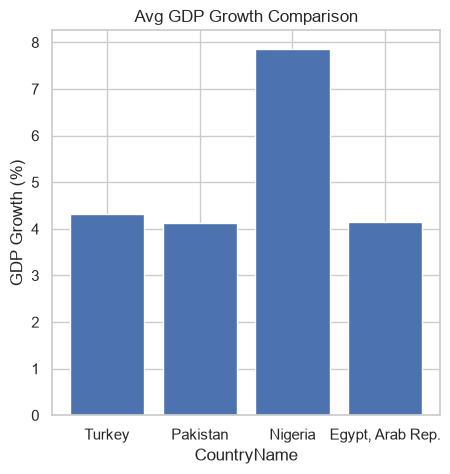

In [21]:

plt.figure(figsize=(5, 5))
plt.bar(data['CountryName'],data['AVG_VALUE'])
plt.title("Avg GDP Growth Comparison")
plt.xlabel("CountryName")
plt.ylabel("GDP Growth (%)")
plt.show()

In [22]:
data =pd.read_sql("""
    SELECT countryName, indicatorName, value, year
    FROM indicators
    WHERE countrycode = 'EGY'
      AND indicatorcode IN (
          'SE.XPD.TOTL.GD.ZS',
          'SE.PRM.ENRL',
          'SE.SEC.ENRL',
          'SE.ADT.LITR.ZS'
      )
      AND year BETWEEN 2000 AND 2015
    ORDER BY year DESC
""",conn)

data


,CountryName,IndicatorName,Value,Year
0,"Egypt, Arab Rep.","Adult literacy rate, population 15+ years, bot...",7.506073e+01,2013
1,"Egypt, Arab Rep.","Enrolment in primary education, both sexes (nu...",1.111310e+07,2013
2,"Egypt, Arab Rep.","Enrolment in secondary education, both sexes (...",8.144505e+06,2013
3,"Egypt, Arab Rep.","Adult literacy rate, population 15+ years, bot...",7.386559e+01,2012
4,"Egypt, Arab Rep.","Enrolment in primary education, both sexes (nu...",1.081964e+07,2012
5,"Egypt, Arab Rep.","Enrolment in secondary education, both sexes (...",7.849734e+06,2012
6,"Egypt, Arab Rep.","Enrolment in primary education, both sexes (nu...",1.026601e+07,2011
7,"Egypt, Arab Rep.","Enrolment in secondary education, both sexes (...",7.745940e+06,2011
8,"Egypt, Arab Rep.","Adult literacy rate, population 15+ years, bot...",7.204785e+01,2010
9,"Egypt, Arab Rep.","Enrolment in primary education, both sexes (nu...",1.054214e+07,2010


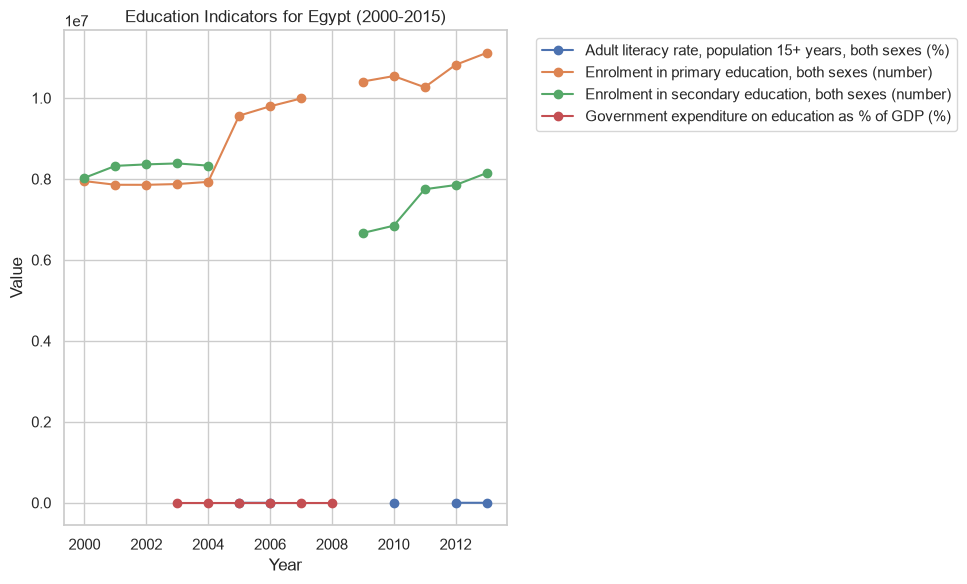

In [23]:

pivot_data = data.pivot(index="Year", columns="IndicatorName", values="Value")

plt.figure(figsize=(10, 6))
for column in pivot_data.columns:
  plt.plot(pivot_data.index, pivot_data[column], marker="o", label=column)

plt.title("Education Indicators for Egypt (2000-2015)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
data = pd.read_sql("""SELECT CountryCode, CountryName, IndicatorName, Value, Year
FROM indicators
WHERE CountryCode IN ('EGY', 'NGA', 'TUR', 'PAK')
  AND IndicatorCode IN (
      'SE.XPD.TOTL.GD.ZS',
      'SE.PRM.ENRL',
      'SE.SEC.ENRL',
      'SE.ADT.LITR.ZS'
  )
  AND Year BETWEEN 2000 AND 2015 """,conn)
data


,CountryCode,CountryName,IndicatorName,Value,Year
0,NGA,Nigeria,"Adult literacy rate, population 15+ years, bot...",54.773178,2003
1,TUR,Turkey,"Adult literacy rate, population 15+ years, bot...",87.365486,2004
2,EGY,"Egypt, Arab Rep.","Adult literacy rate, population 15+ years, bot...",71.408867,2005
3,PAK,Pakistan,"Adult literacy rate, population 15+ years, bot...",49.873646,2005
4,TUR,Turkey,"Adult literacy rate, population 15+ years, bot...",88.229057,2005
...,...,...,...,...,...
137,PAK,Pakistan,Government expenditure on education as % of GD...,2.590780,2009
138,PAK,Pakistan,Government expenditure on education as % of GD...,2.286870,2010
139,PAK,Pakistan,Government expenditure on education as % of GD...,2.221750,2011
140,PAK,Pakistan,Government expenditure on education as % of GD...,2.136280,2012


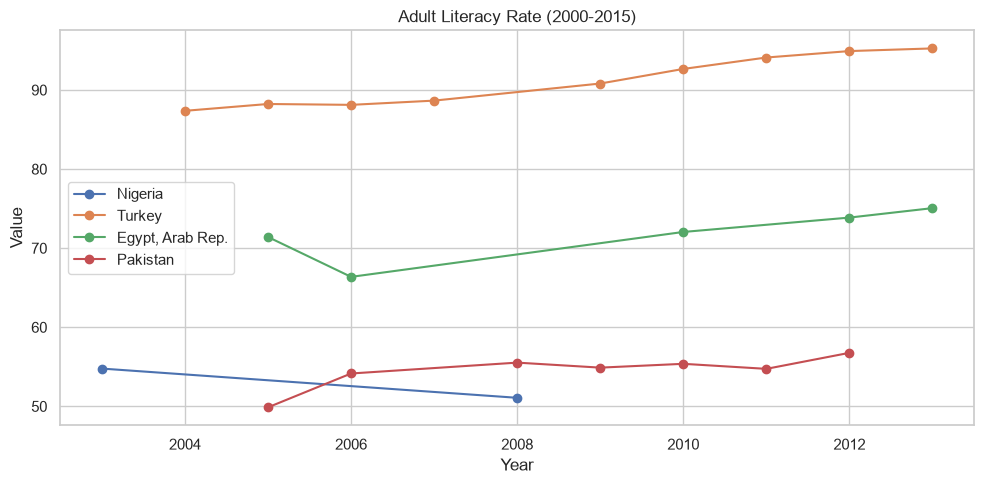

In [25]:
subset_lit = data[
    data["IndicatorName"].str.contains("literacy", case=False, na=False)
]

plt.figure(figsize=(10, 5))
for country in subset_lit["CountryName"].unique():
  country_data = subset_lit[subset_lit["CountryName"] == country]
  plt.plot(
      country_data["Year"], country_data["Value"], marker="o", label=country
  )

plt.title("Adult Literacy Rate (2000-2015)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

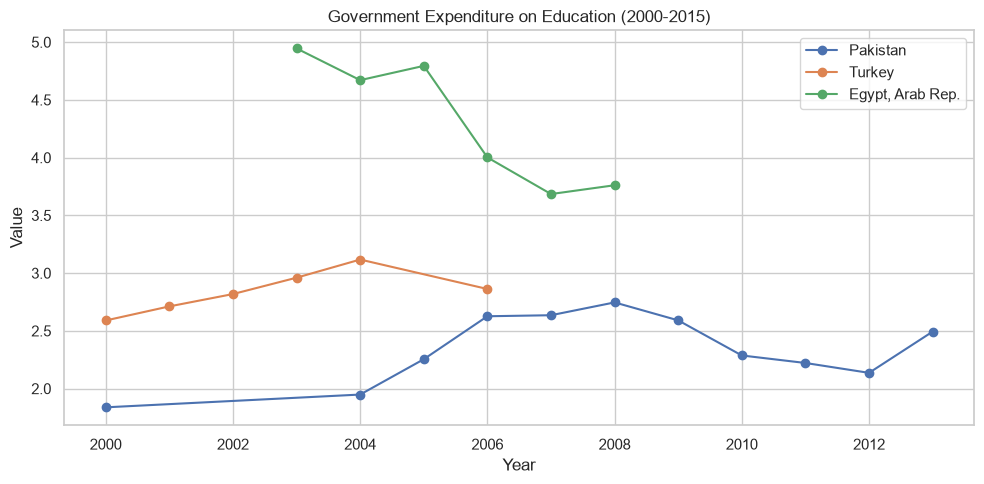

In [26]:

subset_exp = data[
    data["IndicatorName"].str.contains("expenditure", case=False, na=False)
]

plt.figure(figsize=(10, 5))
for country in subset_exp["CountryName"].unique():
  country_data = subset_exp[subset_exp["CountryName"] == country]
  plt.plot(
      country_data["Year"], country_data["Value"], marker="o", label=country
  )

plt.title("Government Expenditure on Education (2000-2015)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

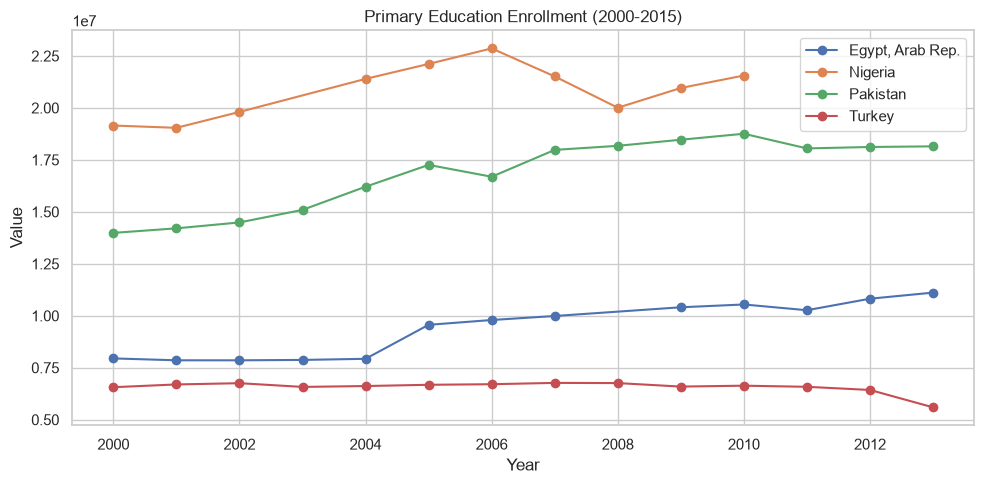

In [27]:

subset_prm = data[
    data["IndicatorName"].str.contains("Primary", case=False, na=False)
]

plt.figure(figsize=(10, 5))
for country in subset_prm["CountryName"].unique():
  country_data = subset_prm[subset_prm["CountryName"] == country]
  plt.plot(
      country_data["Year"], country_data["Value"], marker="o", label=country
  )

plt.title("Primary Education Enrollment (2000-2015)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

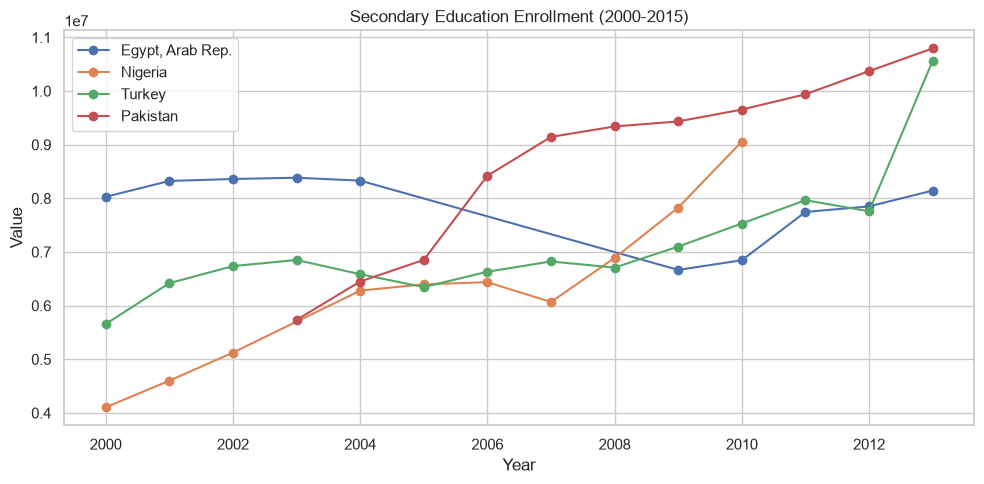

In [28]:

subset_sec = data[
    data["IndicatorName"].str.contains("Secondary", case=False, na=False)
]

plt.figure(figsize=(10, 5))
for country in subset_sec["CountryName"].unique():
  country_data = subset_sec[subset_sec["CountryName"] == country]
  plt.plot(
      country_data["Year"], country_data["Value"], marker="o", label=country
  )

plt.title("Secondary Education Enrollment (2000-2015)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

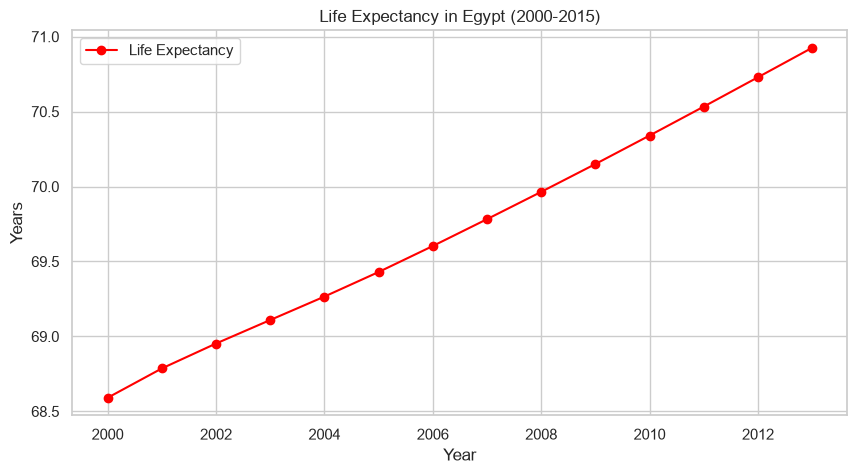

In [29]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'EGY'
    and IndicatorName = 'Life expectancy at birth, total (years)'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Life Expectancy', marker='o', color='red')
plt.xlabel('Year'); plt.ylabel('Years'); plt.title('Life Expectancy in Egypt (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

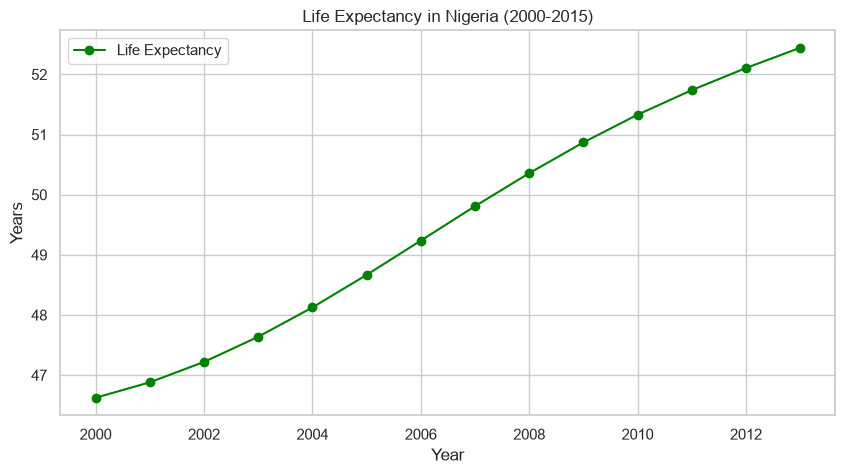

In [30]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'NGA'
    and IndicatorName = 'Life expectancy at birth, total (years)'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Life Expectancy', marker='o', color='green')
plt.xlabel('Year'); plt.ylabel('Years'); plt.title('Life Expectancy in Nigeria (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

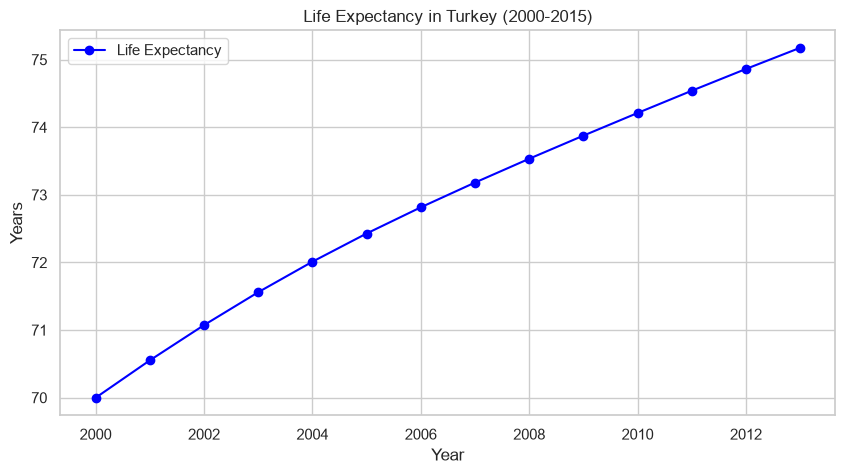

In [31]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'TUR'
    and IndicatorName = 'Life expectancy at birth, total (years)'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Life Expectancy', marker='o', color='blue')
plt.xlabel('Year'); plt.ylabel('Years'); plt.title('Life Expectancy in Turkey (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

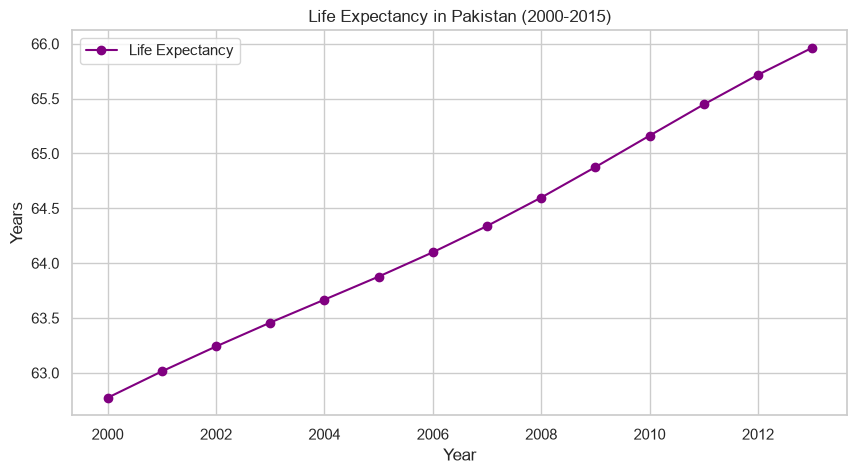

In [32]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'PAK'
    and IndicatorName = 'Life expectancy at birth, total (years)'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Life Expectancy', marker='o', color='purple')
plt.xlabel('Year'); plt.ylabel('Years'); plt.title('Life Expectancy in Pakistan (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

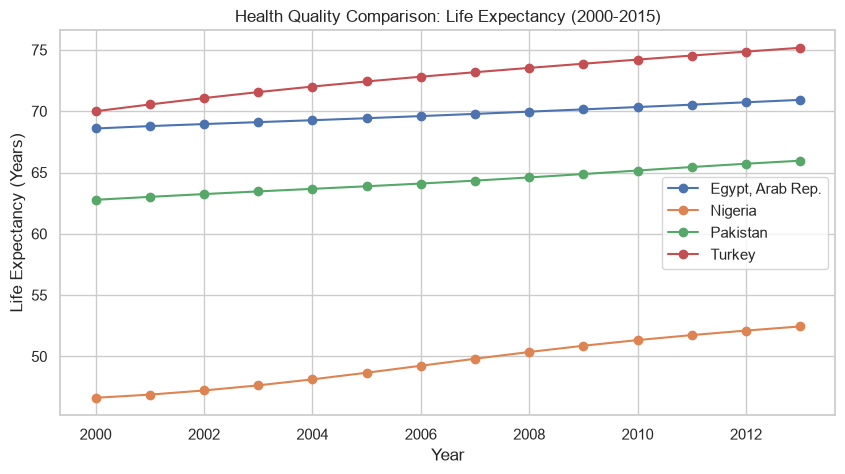

In [33]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode in ('EGY', 'NGA', 'TUR', 'PAK')
    and IndicatorName = 'Life expectancy at birth, total (years)'
    and Year between 2000 and 2015
    order by Year asc;
""", conn)

pivot_data = data.pivot(index='Year', columns='CountryName', values='Value')

plt.figure(figsize=(10, 5))
for column in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[column], marker='o', label=column)

plt.xlabel('Year'); plt.ylabel('Life Expectancy (Years)')
plt.title('Health Quality Comparison: Life Expectancy (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

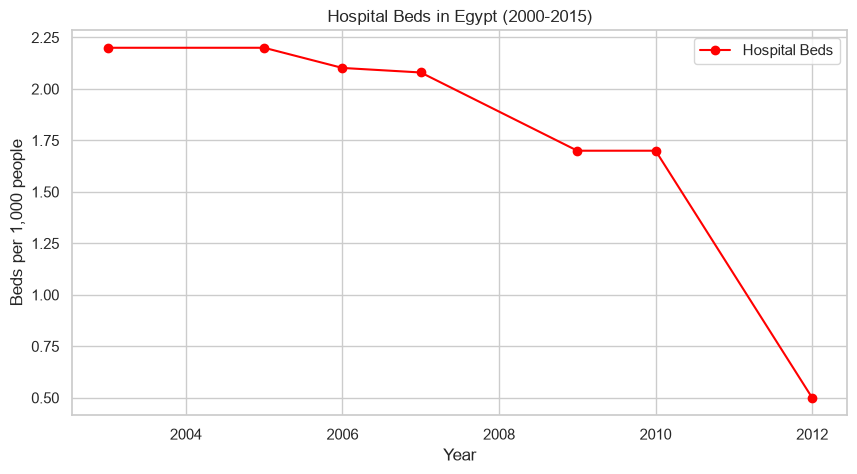

In [36]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'EGY'
    and IndicatorName like 'Hospital beds%'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Hospital Beds', marker='o', color='red')
plt.xlabel('Year'); plt.ylabel('Beds per 1,000 people'); plt.title('Hospital Beds in Egypt (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

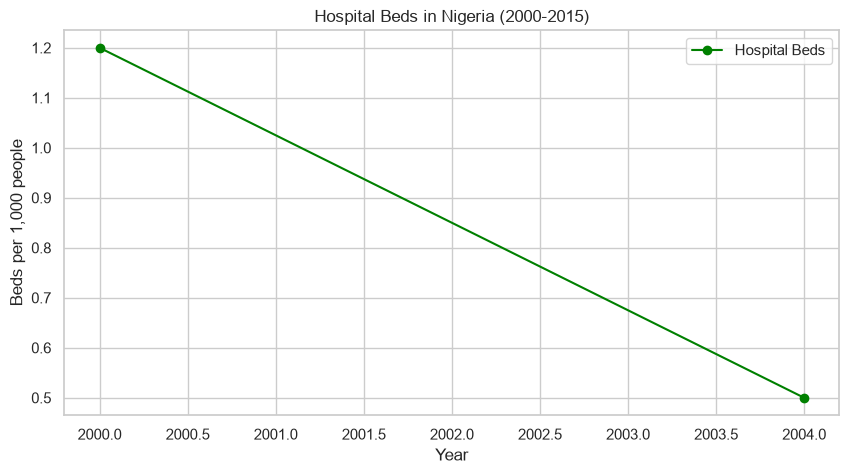

In [37]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'NGA'
    and IndicatorName like 'Hospital beds%'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Hospital Beds', marker='o', color='green')
plt.xlabel('Year'); plt.ylabel('Beds per 1,000 people'); plt.title('Hospital Beds in Nigeria (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

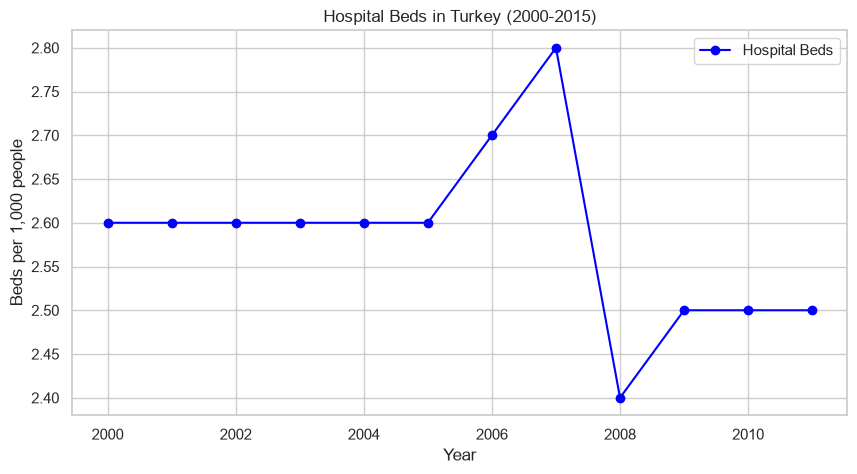

In [38]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'TUR'
    and IndicatorName like 'Hospital beds%'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Hospital Beds', marker='o', color='blue')
plt.xlabel('Year'); plt.ylabel('Beds per 1,000 people'); plt.title('Hospital Beds in Turkey (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

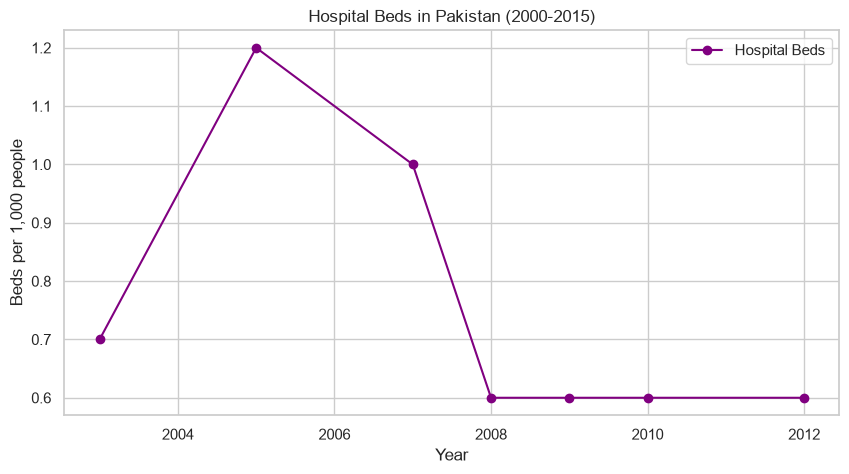

In [39]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'PAK'
    and IndicatorName like 'Hospital beds%'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Hospital Beds', marker='o', color='purple')
plt.xlabel('Year'); plt.ylabel('Beds per 1,000 people'); plt.title('Hospital Beds in Pakistan (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

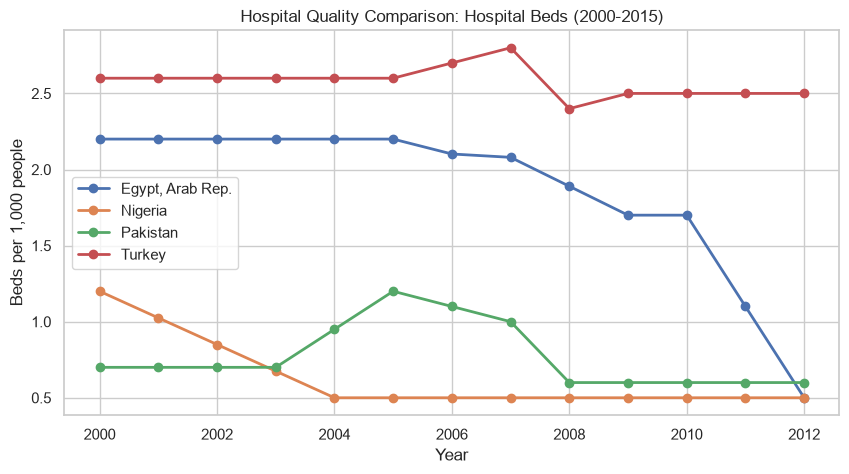

In [48]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode in ('EGY', 'NGA', 'TUR', 'PAK')
    and IndicatorName like 'Hospital beds%'
    and Year between 2000 and 2015
    order by Year asc;
""", conn)

pivot_data = data.pivot(index='Year', columns='CountryName', values='Value')
pivot_data_interpolated = pivot_data.interpolate(method='linear', limit_direction='both')
plt.figure(figsize=(10, 5))
for column in pivot_data_interpolated.columns:
    plt.plot(pivot_data_interpolated.index, pivot_data_interpolated[column], 
             label=column, linestyle='-', marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Beds per 1,000 people')
plt.title('Hospital Quality Comparison: Hospital Beds (2000-2015)')
plt.grid(True)
plt.legend()
plt.show()

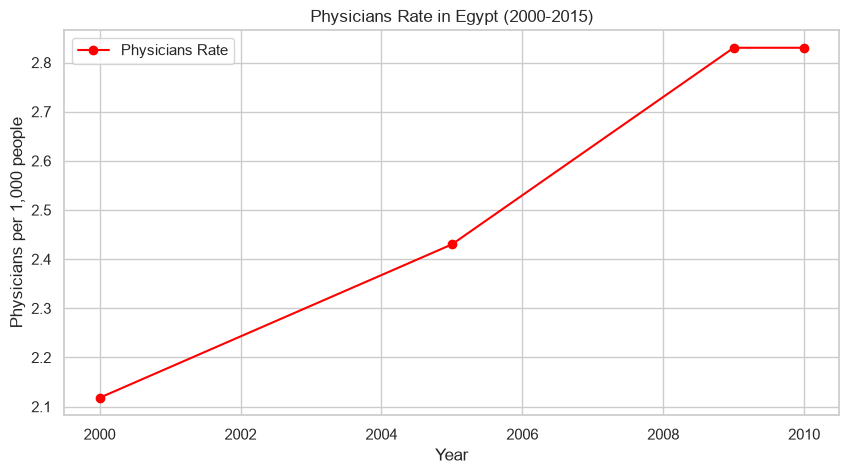

In [42]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'EGY'
    and IndicatorName like 'Physicians%'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Physicians Rate', marker='o', color='red')
plt.xlabel('Year'); plt.ylabel('Physicians per 1,000 people'); plt.title('Physicians Rate in Egypt (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

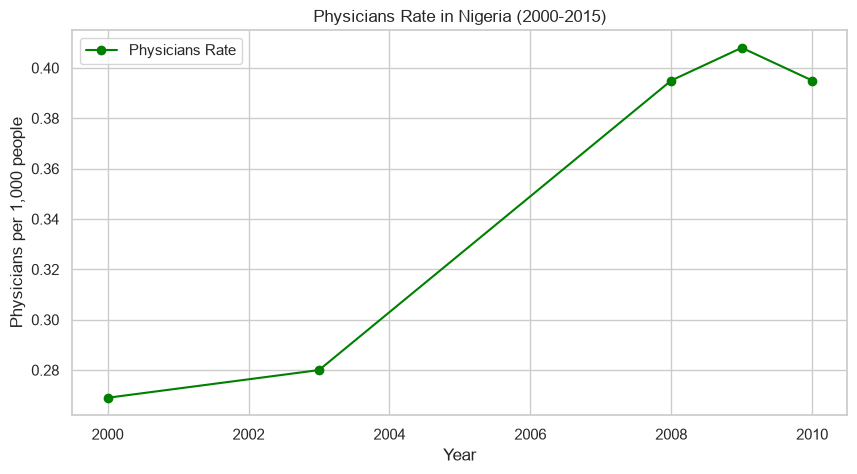

In [43]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'NGA'
    and IndicatorName like 'Physicians%'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Physicians Rate', marker='o', color='green')
plt.xlabel('Year'); plt.ylabel('Physicians per 1,000 people'); plt.title('Physicians Rate in Nigeria (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

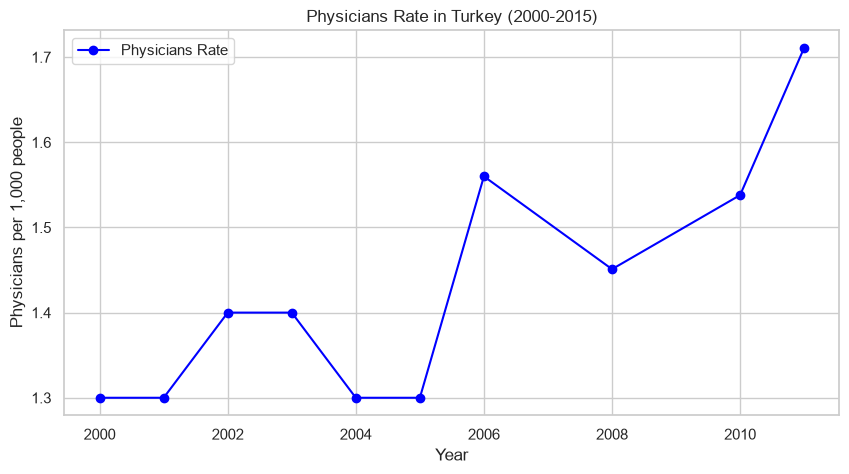

In [44]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'TUR'
    and IndicatorName like 'Physicians%'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Physicians Rate', marker='o', color='blue')
plt.xlabel('Year'); plt.ylabel('Physicians per 1,000 people'); plt.title('Physicians Rate in Turkey (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

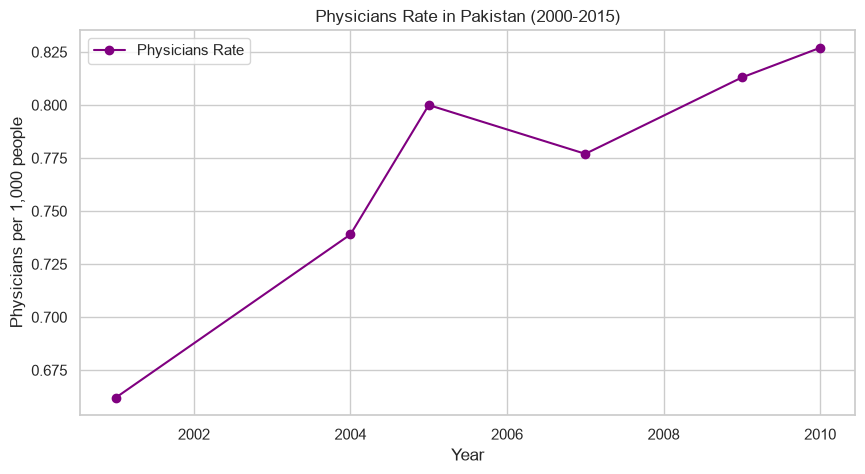

In [45]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode = 'PAK'
    and IndicatorName like 'Physicians%'
    and Year between 2000 and 2015
    order by Year desc;
""", conn)

plt.figure(figsize=(10, 5))
plt.plot(data['Year'], data['Value'], label='Physicians Rate', marker='o', color='purple')
plt.xlabel('Year'); plt.ylabel('Physicians per 1,000 people'); plt.title('Physicians Rate in Pakistan (2000-2015)')
plt.grid(True); plt.legend(); plt.show()

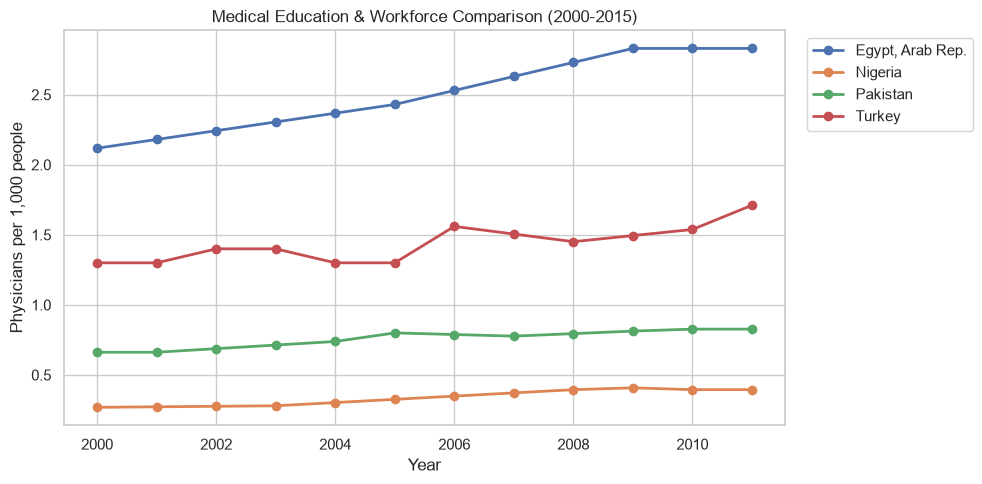

In [50]:
data = pd.read_sql("""
    select CountryName, IndicatorName, Value, Year from Indicators
    where CountryCode in ('EGY', 'NGA', 'TUR', 'PAK')
    and IndicatorName like 'Physicians%'
    and Year between 2000 and 2015
    order by Year asc;
""", conn)

pivot_data = data.pivot(index='Year', columns='CountryName', values='Value')
pivot_data_interpolated = pivot_data.interpolate(method='linear', limit_direction='both')

plt.figure(figsize=(10, 5))
for column in pivot_data_interpolated.columns:
    plt.plot(pivot_data_interpolated.index, pivot_data_interpolated[column], 
             label=column, linestyle='-', marker='o', linewidth=2)

plt.xlabel('Year')
plt.ylabel('Physicians per 1,000 people')
plt.title('Medical Education & Workforce Comparison (2000-2015)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()